In [ ]:
# Casting Defect Detection using CNN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator, image 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.1


In [ ]:
train_dir = "casting_data/train"
test_dir = "casting_data/test"

In [ ]:
print(os.listdir(train_dir))
print(os.listdir(test_dir))


['def_front', 'ok_front']
['def_front', 'ok_front']


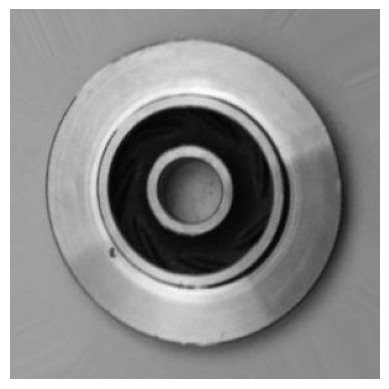

In [ ]:
from tensorflow.keras.preprocessing import image

img_path = os.path.join(
    train_dir,
    "def_front",
    os.listdir(os.path.join(train_dir,"def_front"))[0]
)

img = image.load_img(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 5307 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1326 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 715 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D())

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D())

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 111, 111, 32)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 26, 26, 128)     

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
166/166 [==============================] - 241s 1s/step - loss: 0.6998 - accuracy: 0.6090 - val_loss: 0.4662 - val_accuracy: 0.8092
Epoch 2/15
166/166 [==============================] - 271s 2s/step - loss: 0.4074 - accuracy: 0.8119 - val_loss: 0.2584 - val_accuracy: 0.9110
Epoch 3/15
166/166 [==============================] - 382s 2s/step - loss: 0.2968 - accuracy: 0.8747 - val_loss: 0.2621 - val_accuracy: 0.8884
Epoch 4/15
166/166 [==============================] - 236s 1s/step - loss: 0.2274 - accuracy: 0.9135 - val_loss: 0.2905 - val_accuracy: 0.8665
Epoch 5/15
166/166 [==============================] - 257s 2s/step - loss: 0.2113 - accuracy: 0.9114 - val_loss: 0.1719 - val_accuracy: 0.9268
Epoch 6/15
166/166 [==============================] - 269s 2s/step - loss: 0.1514 - accuracy: 0.9448 - val_loss: 0.1317 - val_accuracy: 0.9615
Epoch 7/15
166/166 [==============================] - 250s 2s/step - loss: 0.1571 - accuracy: 0.9420 - val_loss: 0.2389 - val_accuracy: 0.8846

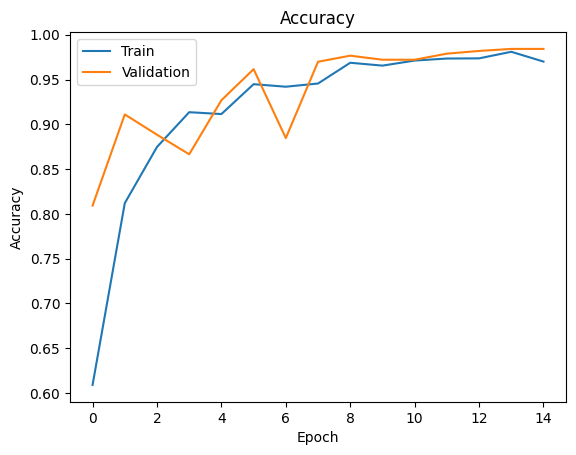

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()
plt.savefig("accuracy_curve.png")

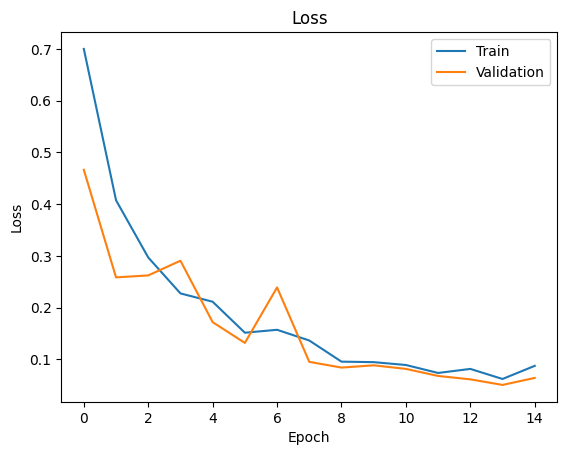

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()
plt.savefig("loss_curve.png")

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Accuracy:", accuracy)

23/23 [==============================] - 7s 282ms/step - loss: 0.0717 - accuracy: 0.9790
Accuracy: 0.9790209531784058


In [ ]:
predictions = model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int)

23/23 [==============================] - 7s 261ms/step


In [ ]:
print(
    classification_report(
        test_generator.classes,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       453
           1       0.95      1.00      0.97       262

    accuracy                           0.98       715
   macro avg       0.97      0.98      0.98       715
weighted avg       0.98      0.98      0.98       715



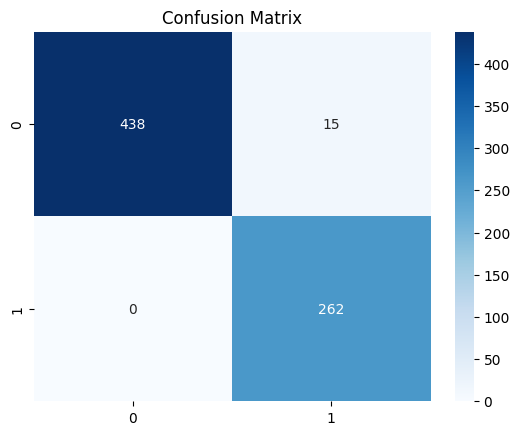

<Figure size 640x480 with 0 Axes>

In [ ]:
cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()
plt.savefig("confusion_matrix.png")

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

9406464/9406464 [==============================] - 1s 0us/step


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
166/166 [==============================] - 249s 1s/step - loss: 0.2365 - accuracy: 0.9007 - val_loss: 0.1085 - val_accuracy: 0.9615
Epoch 2/10
166/166 [==============================] - 369s 2s/step - loss: 0.1069 - accuracy: 0.9627 - val_loss: 0.0696 - val_accuracy: 0.9759
Epoch 3/10
166/166 [==============================] - 196s 1s/step - loss: 0.0721 - accuracy: 0.9748 - val_loss: 0.0593 - val_accuracy: 0.9842
Epoch 4/10
166/166 [==============================] - 568s 3s/step - loss: 0.0668 - accuracy: 0.9761 - val_loss: 0.0534 - val_accuracy: 0.9842
Epoch 5/10
166/166 [==============================] - 194s 1s/step - loss: 0.0580 - accuracy: 0.9796 - val_loss: 0.0630 - val_accuracy: 0.9781
Epoch 6/10
166/166 [==============================] - 193s 1s/step - loss: 0.0573 - accuracy: 0.9798 - val_loss: 0.0479 - val_accuracy: 0.9864
Epoch 7/10
166/166 [==============================] - 231s 1s/step - loss: 0.0463 - accuracy: 0.9851 - val_loss: 0.0414 - val_accuracy: 0.9887

In [ ]:
loss, cnn_acc = model.evaluate(test_generator)
print("CNN Accuracy:", cnn_acc)

mobile_loss, mobile_acc = transfer_model.evaluate(test_generator)
print("MobileNetV2 Accuracy:", mobile_acc)

23/23 [==============================] - 7s 270ms/step - loss: 0.0717 - accuracy: 0.9790
CNN Accuracy: 0.9790209531784058
23/23 [==============================] - 14s 581ms/step - loss: 0.0371 - accuracy: 0.9930
MobileNetV2 Accuracy: 0.9930070042610168


In [ ]:
model.save("cnn_model.h5")

transfer_model.save("mobilenet_model.h5")

In [ ]:
transfer_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense_6 (Dense)             (None, 128)               163968    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2,422,081
Trainable params: 164,097
Non-

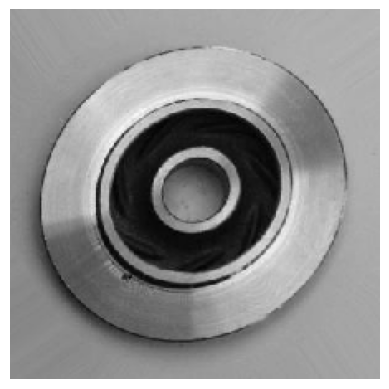

In [ ]:
img_path = os.path.join(
    test_dir,
    "def_front",
    os.listdir(os.path.join(test_dir, "def_front"))[0]
)

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = transfer_model.predict(img_array)

print(prediction)

1/1 [==============================] - 2s 2s/step
[[0.00026197]]


In [ ]:
base_model = transfer_model.layers[0]

feature_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("Conv_1").output
)

feature_maps = feature_model.predict(img_array)

print(feature_maps.shape)
print(feature_maps.min())
print(feature_maps.max())

1/1 [==============================] - 2s 2s/step
(1, 7, 7, 1280)
-5.1605606
5.209361


In [ ]:
inputs = transfer_model.input

x = transfer_model.layers[0](inputs)
conv_output = x

x = transfer_model.layers[1](x)
x = transfer_model.layers[2](x)
x = transfer_model.layers[3](x)
predictions = transfer_model.layers[4](x)

grad_model = tf.keras.models.Model(
    inputs=inputs,
    outputs=[conv_output, predictions]
)

print("Grad model created successfully")

Grad model created successfully


In [ ]:
for layer in model.layers:
    print(layer.name)
print("Mean:", heatmap.mean())

conv2d_6
max_pooling2d_6
conv2d_7
max_pooling2d_7
conv2d_8
max_pooling2d_8
flatten_2
dense_4
dropout_2
dense_5
Mean: 0.0


In [ ]:
conv_outputs, preds = grad_model(img_array)

print(conv_outputs.shape)
print(preds.numpy())

(1, 7, 7, 1280)
[[0.00026197]]


In [ ]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, 0]

grads = tape.gradient(
    loss,
    conv_outputs
)

print("Gradient shape:", grads.shape)
print("Gradient max:", tf.reduce_max(grads).numpy())
print("Gradient min:", tf.reduce_min(grads).numpy())

Gradient shape: (1, 7, 7, 1280)
Gradient max: 5.1275365e-06
Gradient min: -7.227868e-06


In [ ]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    pooled_grads * conv_outputs,
    axis=-1
)

heatmap = tf.maximum(
    heatmap,
    0
)

heatmap = heatmap / (
    tf.reduce_max(heatmap) + 1e-10
)

heatmap = heatmap.numpy()

print("Shape:", heatmap.shape)
print("Min:", heatmap.min())
print("Max:", heatmap.max())
print("Mean:", heatmap.mean())

Shape: (7, 7)
Min: 0.0
Max: 0.9999953
Mean: 0.052353017


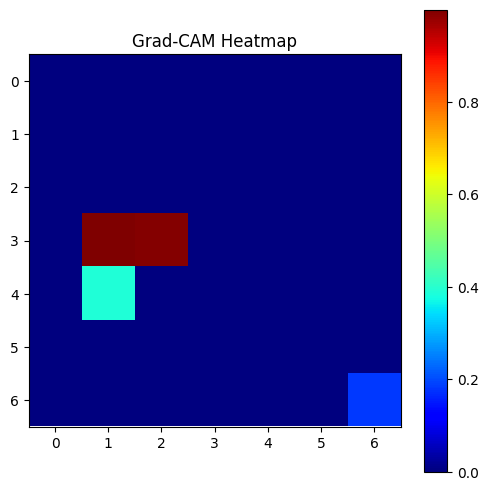

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(
    heatmap,
    cmap="jet"
)
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

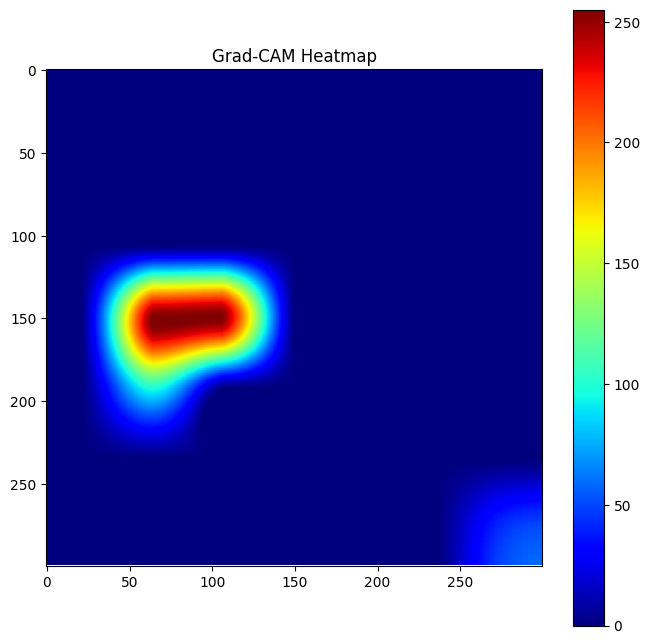

In [ ]:
from PIL import Image

original_img = Image.open(img_path)

original_img = np.array(original_img)

heatmap_resized = np.array(
    Image.fromarray(
        np.uint8(heatmap * 255)
    ).resize(
        (original_img.shape[1], original_img.shape[0])
    )
)

plt.figure(figsize=(8,8))
plt.imshow(heatmap_resized, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

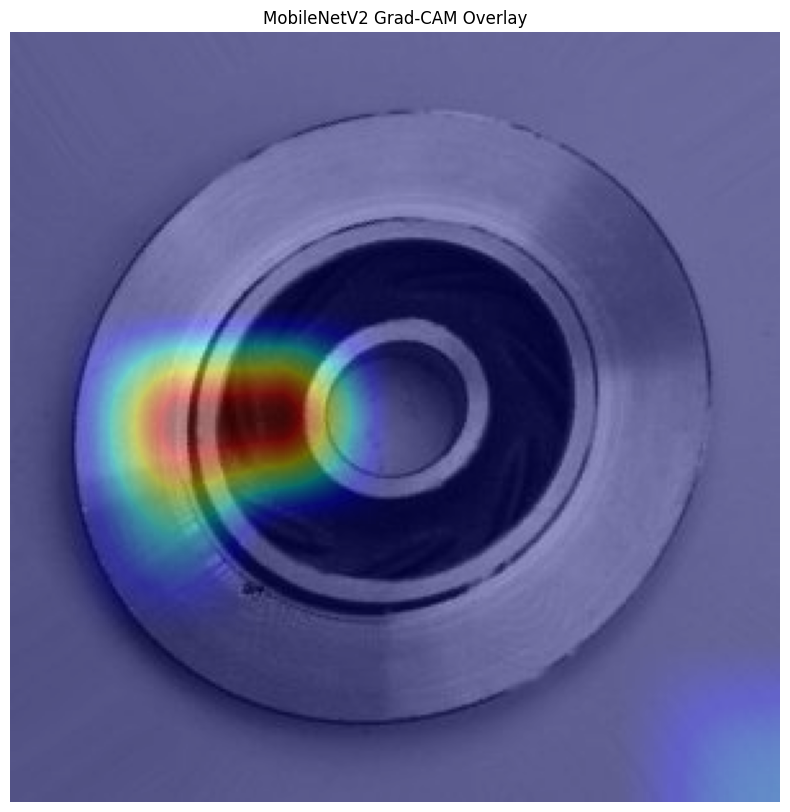

In [ ]:
original_img = np.array(Image.open(img_path))

heatmap_resized = np.array(
    Image.fromarray(
        np.uint8(heatmap * 255)
    ).resize(
        (original_img.shape[1],
         original_img.shape[0])
    )
)

plt.figure(figsize=(10,10))

plt.imshow(original_img)

plt.imshow(
    heatmap_resized,
    cmap='jet',
    alpha=0.4
)

plt.axis("off")
plt.title("MobileNetV2 Grad-CAM Overlay")

plt.show()

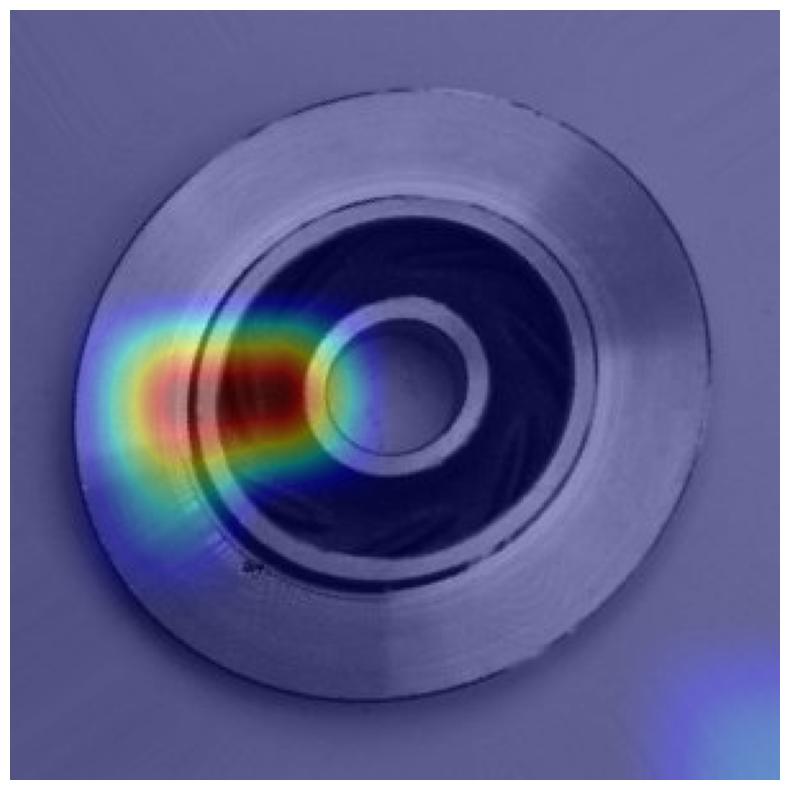

In [ ]:
plt.figure(figsize=(10,10))

plt.imshow(original_img)

plt.imshow(
    heatmap_resized,
    cmap='jet',
    alpha=0.4
)

plt.axis("off")

plt.savefig(
    "gradcam_mobilenetv2_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()